Dataset shape: (1338, 7)

First 5 rows:
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Missing values before cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


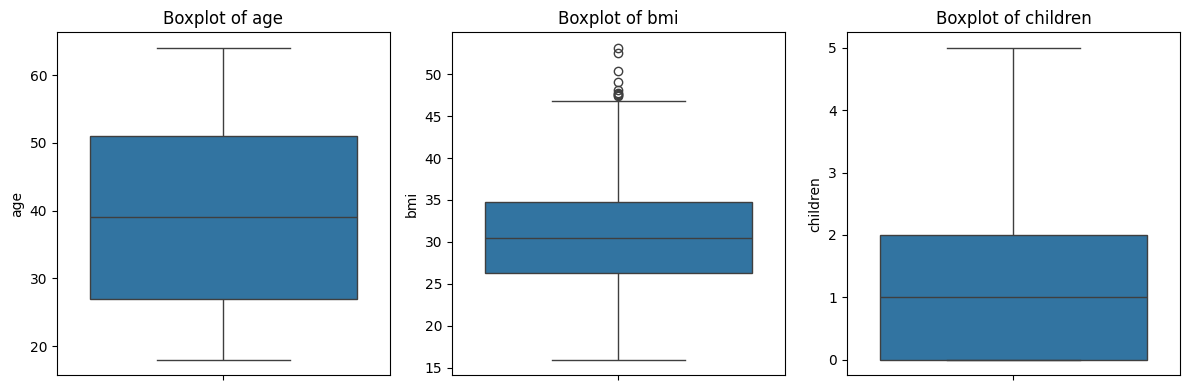

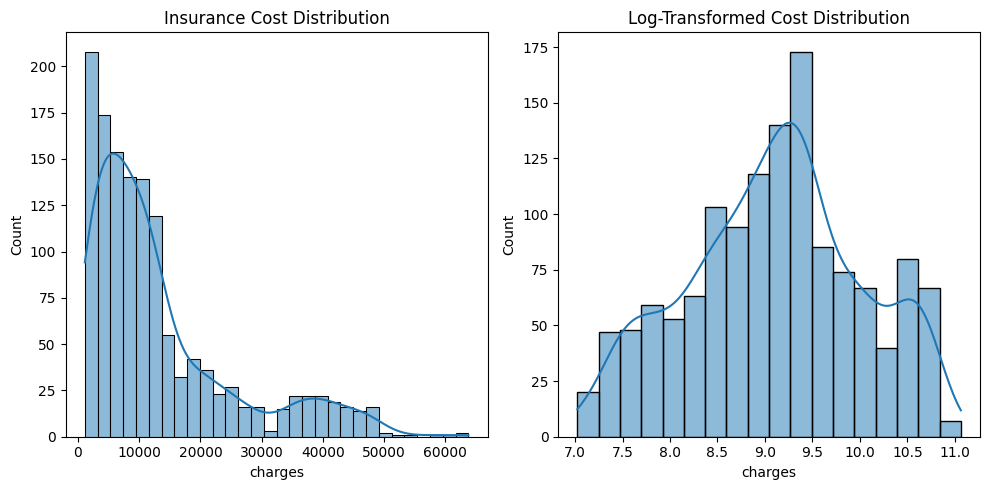

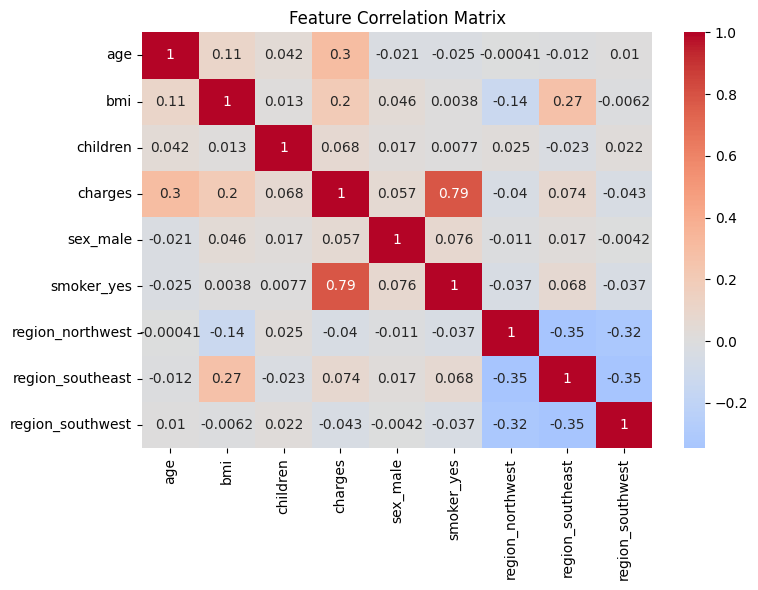

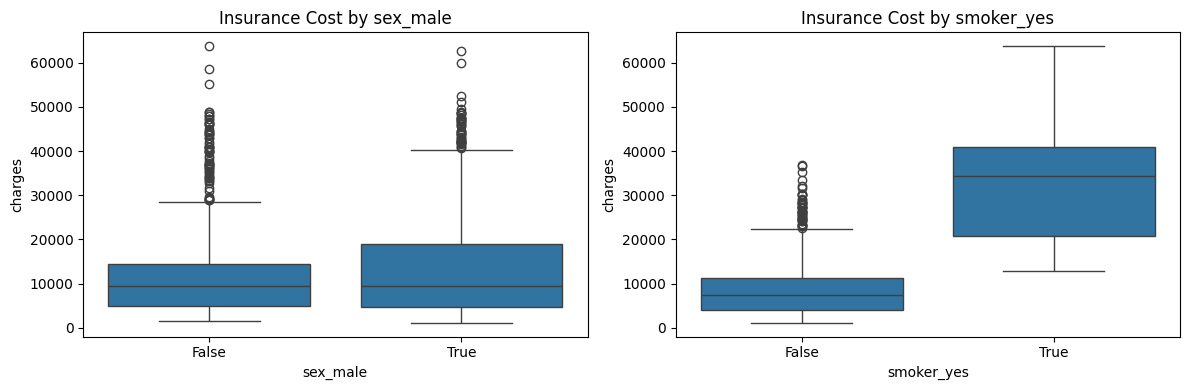


Processed Data Summary:
----------------------------------------
Numerical features: ['age', 'bmi', 'children']
Categorical features (encoded): ['sex_male', 'smoker_yes', 'region_northwest', 'region_southeast', 'region_southwest']

Final dataset sample:
   age    bmi  children     charges  sex_male  smoker_yes  region_northwest
0   19  27.90         0  16884.9240     False        True             False
1   18  33.77         1   1725.5523      True       False             False
2   28  33.00         3   4449.4620      True       False             False

Final Dataset Shapes:
------------------------------
X_train: (1070, 14)
y_train: (1070,)
X_test: (268, 14)
y_test: (268,)


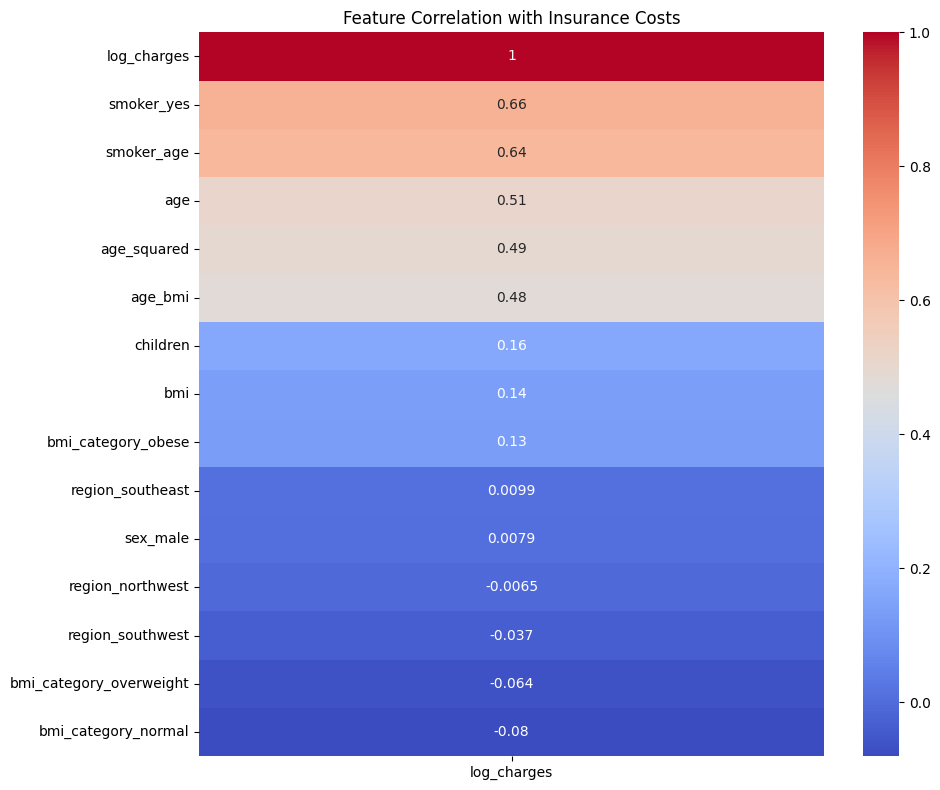


Processed data saved to CSV files


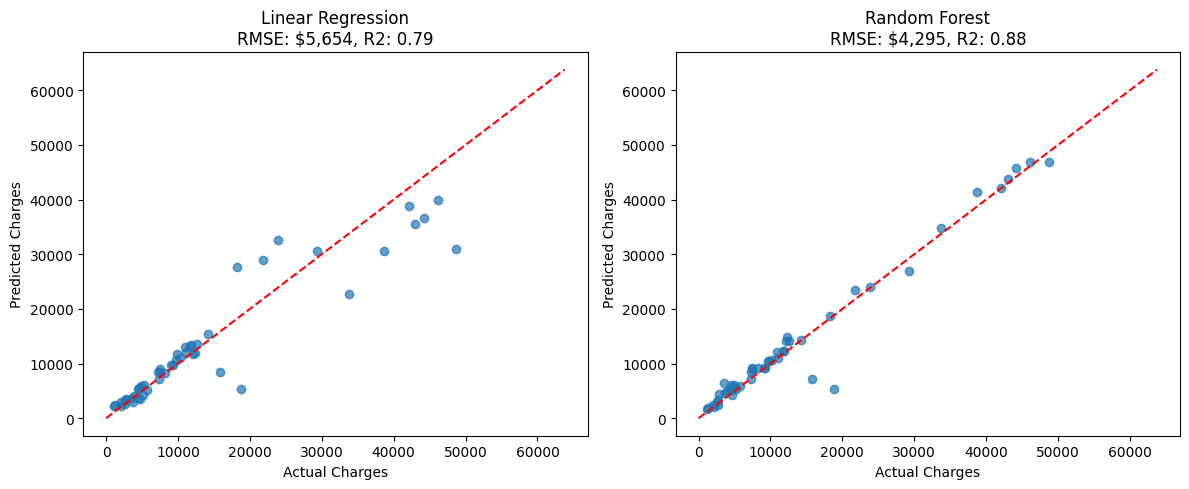


Regression Performance:
----------------------------------------
                          RMSE        R2
Linear Regression  5654.017819  0.794086
Random Forest      4294.675262  0.881196


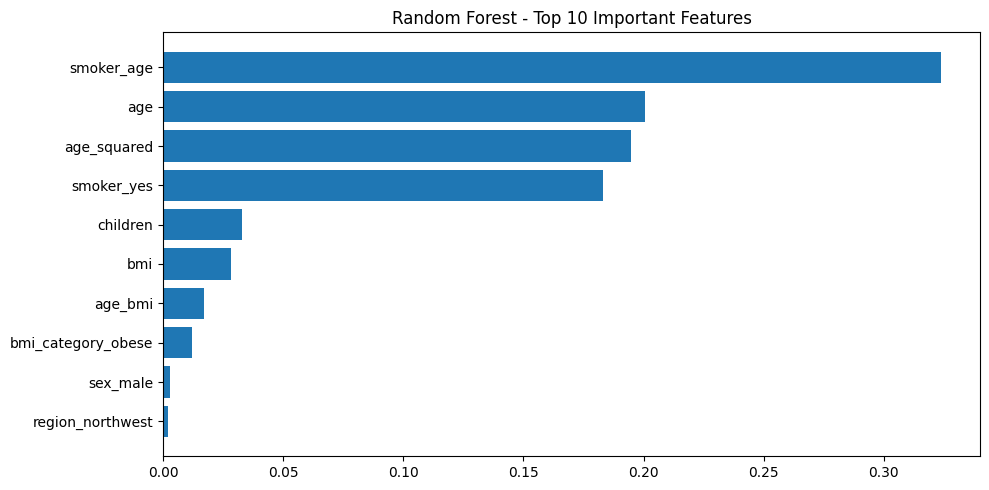


Linear Regression Performance:
----------------------------------------
RMSE: $5,654.02
R² Score: 0.794
MAE: $3,091.42
Average Error: 22.2%


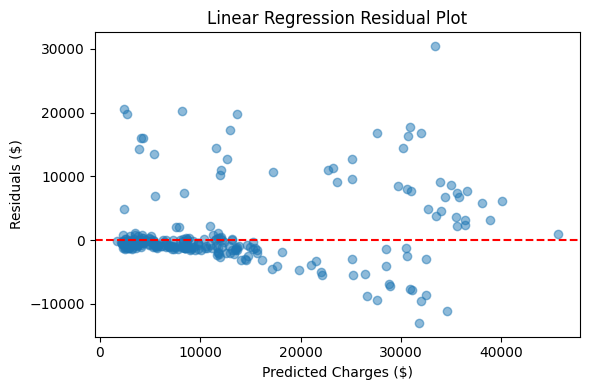


Random Forest Performance:
----------------------------------------
RMSE: $4,294.68
R² Score: 0.881
MAE: $1,974.43
Average Error: 18.0%


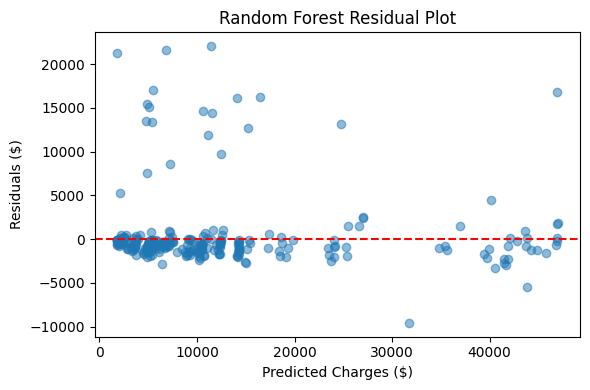


Model Comparison:
----------------------------------------
               Linear Regression  Random Forest
RMSE                 5654.017819    4294.675262
R2                      0.794086       0.881196
Avg Error (%)          22.213065      17.997747

Metrics saved to 'regression_metrics.csv'

Regression Model Comparison
               Linear Regression  Random Forest  Improvement (%)
RMSE                 5654.017819    4294.675262        24.042064
R2                      0.794086       0.881196       -10.969819
Avg Error (%)          22.213065      17.997747        18.976749


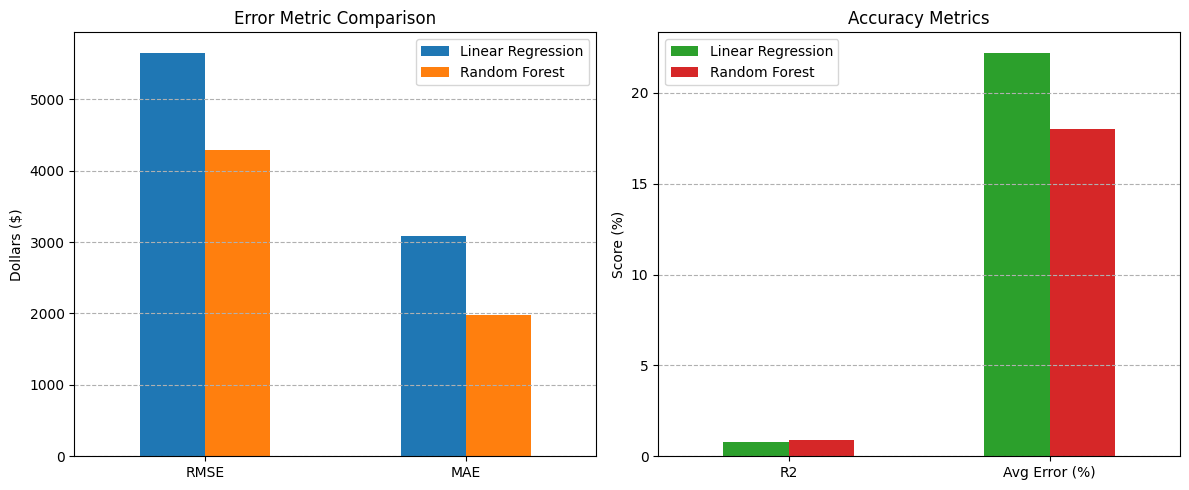


Key Observations:
--------------------------------------------------
1. Random Forest reduces prediction error by $1,359 (24.0%) compared to Linear Regression
2. R² improvement: -11.0% (Higher explains more variance)
3. Average error drops from 22.2% to 18.0%

Comparison report saved to 'model_comparison_report.csv'

Starting Grid Search (this may take several minutes)...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

Grid Search Complete!
Best RMSE: 0.38759427773581206
Best Parameters:
- bootstrap: False
- max_depth: 7
- max_features: sqrt
- min_samples_split: 5
- n_estimators: 50

Tuned Model Performance:
----------------------------------------
RMSE: $4,434.46 (Improvement: -3.3%)
R²: 0.873


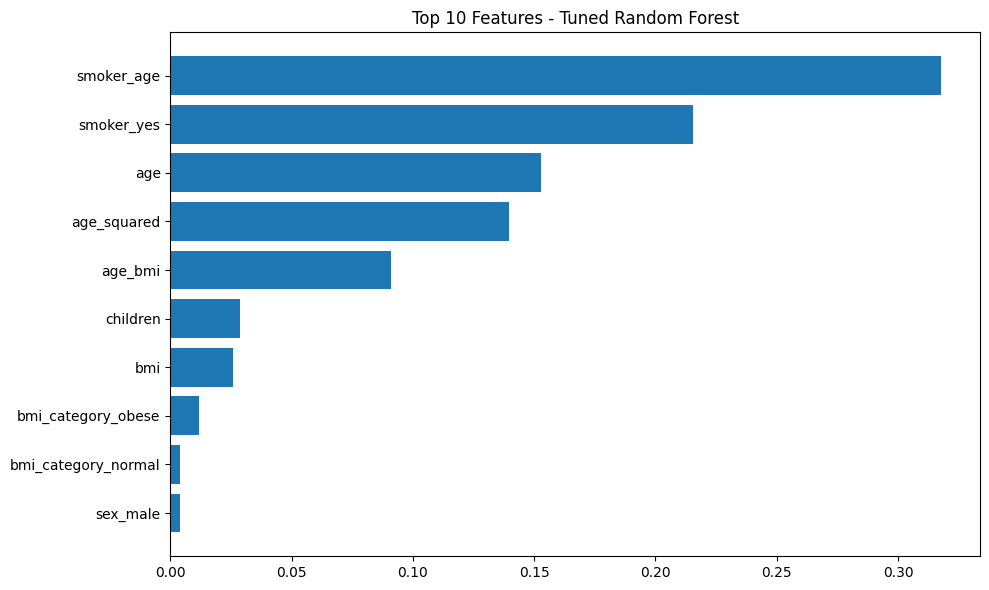


Tuned model saved to 'tuned_rf_model.pkl'

Final Comparison:
----------------------------------------
               Random Forest     Tuned RF
RMSE             4294.675262  4434.464303
R2                  0.881196     0.873336
MAE              1974.430374          NaN
Avg Error (%)      17.997747    19.472384


In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import GridSearchCV


#  ---    Task 2   ---


# Step 1: Loading Data, Data Pre-processing, EDA
data = pd.read_csv('/content/sample_data/insurance.csv')
print("Dataset shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

# --- 2. Data Preprocessing ---
# A. Handle missing values
print("\nMissing values before cleaning:")
print(data.isna().sum())

# B. Convert categorical variables -
# Method 1: One-hot encoding -
data = pd.get_dummies(data, columns=['sex', 'smoker', 'region'], drop_first=True)


# C. Check for outliers in numerical features
num_cols = ['age', 'bmi', 'children']
plt.figure(figsize=(12, 4))
for i, col in enumerate(num_cols, 1):
    plt.subplot(1, 3, i)
    sns.boxplot(data=data, y=col)
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.savefig('numerical_outliers.png')
plt.show()


# --- 3. Exploratory Data Analysis (EDA) ---
# A. Target variable distribution
plt.figure(figsize=(10, 5))
plt.subplot(121)
sns.histplot(data['charges'], kde=True)
plt.title('Insurance Cost Distribution')

plt.subplot(122)
sns.histplot(np.log1p(data['charges']), kde=True)
plt.title('Log-Transformed Cost Distribution')
plt.tight_layout()
plt.savefig('target_distribution.png')
plt.show()


# B. Correlation analysis
plt.figure(figsize=(8, 6))
corr = data.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig('correlation_matrix.png')
plt.show()


# C. Categorical analysis
cat_cols = ['sex_male', 'smoker_yes']  # After one-hot encoding
plt.figure(figsize=(12, 4))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(data=data, x=col, y='charges')
    plt.title(f'Insurance Cost by {col}')
plt.tight_layout()
plt.savefig('categorical_analysis.png')
plt.show()


# --- 4. Data Summary ---
print("\nProcessed Data Summary:")
print("-" * 40)
print("Numerical features:", num_cols)
print("Categorical features (encoded):", [c for c in data.columns if c not in num_cols+['charges']])
print("\nFinal dataset sample:")
print(data.iloc[:3, :7])  # Show first 3 rows, first 7 columns





# Step 2: Feature Engineering, Creating Train, and Test Datasets

# --- 1. Feature Engineering ---
# A. Log-transform the target variable (to handle right-skewness)
data['log_charges'] = np.log1p(data['charges'])

# B. Create interaction terms
data['age_bmi'] = data['age'] * data['bmi']
data['smoker_age'] = data['smoker_yes'] * data['age']

# C. Create BMI categories (binning)
data['bmi_category'] = pd.cut(data['bmi'],
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['underweight', 'normal', 'overweight', 'obese'])

# D. Polynomial features for age
poly = PolynomialFeatures(degree=2, include_bias=False)
data[['age', 'age_squared']] = poly.fit_transform(data[['age']])[:, :2]

# --- 2. Prepare Final Features ---
# Select features and target
X = data.drop(['charges', 'log_charges'], axis=1)  # Keep all engineered features
y = data['log_charges']  # Using log-transformed target for better performance

# One-hot encode remaining categoricals
X = pd.get_dummies(X, columns=['bmi_category'], drop_first=True)

# --- 3. Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# --- 4. Feature Scaling ---
scaler = StandardScaler()
num_cols = ['age', 'bmi', 'children', 'age_bmi', 'smoker_age', 'age_squared']
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# --- 5. Verify Data Shapes ---
print("\nFinal Dataset Shapes:")
print("-" * 30)
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")


# --- 6. Feature Correlation Check ---
plt.figure(figsize=(10, 8))
corr = pd.concat([X_train, y_train], axis=1).corr()
sns.heatmap(corr[['log_charges']].sort_values('log_charges', ascending=False),
            annot=True, cmap='coolwarm')
plt.title("Feature Correlation with Insurance Costs")
plt.tight_layout()
plt.savefig('feature_correlation.png')
plt.show()

# --- 7. Save Processed Data ---
X_train.to_csv('X_train.csv', index=False)
X_test.to_csv('X_test.csv', index=False)
y_train.to_csv('y_train.csv', index=False)
y_test.to_csv('y_test.csv', index=False)
print("\nProcessed data saved to CSV files")








# Step 3: Apply at least 2 algorithms for regression (Training and Testing)
# --- 1. Initialize Models ---
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=5
    )
}

# --- 2. Train & Evaluate Models ---
results = {}
plt.figure(figsize=(12, 5))

for i, (name, model) in enumerate(models.items(), 1):
    # Train model
    model.fit(X_train, y_train)

    # Predictions (in log scale)
    y_pred = model.predict(X_test)

    # Convert back to original scale
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred)

    # Calculate metrics
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
    r2 = r2_score(y_test_orig, y_pred_orig)

    # Store results
    results[name] = {'RMSE': rmse, 'R2': r2}

    # Plot actual vs predicted (first 50 samples)
    plt.subplot(1, 2, i)
    plt.scatter(y_test_orig[:50], y_pred_orig[:50], alpha=0.7)
    plt.plot([0, max(y_test_orig)], [0, max(y_test_orig)], 'r--')
    plt.xlabel('Actual Charges')
    plt.ylabel('Predicted Charges')
    plt.title(f'{name}\nRMSE: ${rmse:,.0f}, R2: {r2:.2f}')

plt.tight_layout()
plt.savefig('regression_results.png')
plt.show()

# --- 3. Display Results ---
print("\nRegression Performance:")
print("-" * 40)
print(pd.DataFrame(results).T)


# --- 4. Feature Importance (Random Forest) ---
if hasattr(models["Random Forest"], 'feature_importances_'):
    plt.figure(figsize=(10, 5))
    importances = models["Random Forest"].feature_importances_
    sorted_idx = np.argsort(importances)[-10:]  # Top 10 features
    plt.barh(range(len(sorted_idx)), importances[sorted_idx], color='#1f77b4')
    plt.yticks(range(len(sorted_idx)), X_train.columns[sorted_idx])
    plt.title('Random Forest - Top 10 Important Features')
    plt.tight_layout()
    plt.savefig('rf_feature_importance.png')
    plt.show()


# --- 5. Save Predictions ---
pd.DataFrame({
    'Actual': y_test_orig,
    'LR_Pred': np.expm1(models["Linear Regression"].predict(X_test)),
    'RF_Pred': np.expm1(models["Random Forest"].predict(X_test))
}).to_csv('regression_predictions.csv', index=False)




# Step 4: Generate at least 2 Evaluation Metrics on each algorithm.

def evaluate_regression(name, y_true, y_pred_log, model=None):
    """Calculate and display regression metrics"""
    # Convert from log scale to original dollars
    y_true_orig = np.expm1(y_true)
    y_pred_orig = np.expm1(y_pred_log)

    # Calculate metrics
    metrics = {
        'RMSE': np.sqrt(mean_squared_error(y_true_orig, y_pred_orig)),
        'R2': r2_score(y_true_orig, y_pred_orig),
        'MAE': mean_absolute_error(y_true_orig, y_pred_orig),
        'Avg Error (%)': np.mean(np.abs(y_pred_orig - y_true_orig) / y_true_orig) * 100
    }

    # Print results
    print(f"\n{name} Performance:")
    print("-" * 40)
    print(f"RMSE: ${metrics['RMSE']:,.2f}")
    print(f"R² Score: {metrics['R2']:.3f}")
    print(f"MAE: ${metrics['MAE']:,.2f}")
    print(f"Average Error: {metrics['Avg Error (%)']:.1f}%")

# Residual plot
    plt.figure(figsize=(6, 4))
    residuals = y_true_orig - y_pred_orig
    plt.scatter(y_pred_orig, residuals, alpha=0.5)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Predicted Charges ($)')
    plt.ylabel('Residuals ($)')
    plt.title(f'{name} Residual Plot')
    plt.tight_layout()
    plt.savefig(f'{name.lower().replace(" ", "_")}_residuals.png')
    plt.show()

    return metrics

# --- 2. Evaluate Linear Regression ---
lr_pred = models["Linear Regression"].predict(X_test)
lr_metrics = evaluate_regression("Linear Regression", y_test, lr_pred)

# --- 3. Evaluate Random Forest ---
rf_pred = models["Random Forest"].predict(X_test)
rf_metrics = evaluate_regression("Random Forest", y_test, rf_pred)

# --- 4. Comparative Results ---
results = pd.DataFrame({
    'Linear Regression': lr_metrics,
    'Random Forest': rf_metrics
})

print("\nModel Comparison:")
print("-" * 40)
print(results[['Linear Regression', 'Random Forest']].loc[['RMSE', 'R2', 'Avg Error (%)']])


# --- 5. Save Metrics ---
results.to_csv('regression_metrics.csv')
print("\nMetrics saved to 'regression_metrics.csv'")






# Step 5: Comparing the results.

# --- 1. Load Evaluation Metrics ---
metrics = pd.read_csv('regression_metrics.csv', index_col=0)

# --- 2. Print Key Comparison Table ---
print("\nRegression Model Comparison")
print("=" * 50)
comparison = metrics.loc[['RMSE', 'R2', 'Avg Error (%)']]
comparison['Improvement (%)'] = ((comparison['Linear Regression'] - comparison['Random Forest']) /
                                  comparison['Linear Regression']) * 100
print(comparison)



# --- 3. Visual Comparison ---
plt.figure(figsize=(12, 5))

# Metric comparison plot
plt.subplot(121)
metrics.loc[['RMSE', 'MAE']].plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#ff7f0e'])
plt.title('Error Metric Comparison')
plt.ylabel('Dollars ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')


# R² and Avg Error plot
plt.subplot(122)
metrics.loc[['R2', 'Avg Error (%)']].plot(kind='bar', ax=plt.gca(), color=['#2ca02c', '#d62728'])
plt.title('Accuracy Metrics')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300)
plt.show()



# --- 4. Detailed Performance Analysis ---
print("\nKey Observations:")
print("-" * 50)
print(f"1. Random Forest reduces prediction error by ${metrics.loc['RMSE', 'Linear Regression'] - metrics.loc['RMSE', 'Random Forest']:,.0f} "
      f"({comparison.loc['RMSE', 'Improvement (%)']:.1f}%) compared to Linear Regression")
print(f"2. R² improvement: {comparison.loc['R2', 'Improvement (%)']:.1f}% "
      "(Higher explains more variance)")
print(f"3. Average error drops from {metrics.loc['Avg Error (%)', 'Linear Regression']:.1f}% "
      f"to {metrics.loc['Avg Error (%)', 'Random Forest']:.1f}%")


# --- 5. Save Comparison Report ---
comparison.to_csv('model_comparison_report.csv')
print("\nComparison report saved to 'model_comparison_report.csv'")



# Step 6: Fine Tune the best algorithm.
# --- 1. Prepare Data ---
# (Using X_train/y_train from Step 2)

# --- 2. Define Hyperparameter Grid ---
param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False]
}

# --- 3. Initialize Grid Search ---
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='neg_root_mean_squared_error',  # Optimize for RMSE
    cv=5,                                   # 5-fold cross-validation
    n_jobs=-1,                              # Use all CPU cores
    verbose=2
)

# --- 4. Execute Grid Search ---
print("\nStarting Grid Search (this may take several minutes)...")
grid_search.fit(X_train, y_train)


# --- 5. Results Analysis ---
print("\nGrid Search Complete!")
print("Best RMSE:", -grid_search.best_score_)
print("Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"- {param}: {value}")


# --- 6. Train Final Model ---
tuned_rf = grid_search.best_estimator_
tuned_rf.fit(X_train, y_train)

# --- 7. Evaluate Tuned Model ---
y_pred = tuned_rf.predict(X_test)
y_test_orig = np.expm1(y_test)
y_pred_orig = np.expm1(y_pred)

final_rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred_orig))
final_r2 = r2_score(y_test_orig, y_pred_orig)
improvement = ((results.loc['RMSE', 'Random Forest'] - final_rmse) /
              results.loc['RMSE', 'Random Forest']) * 100

print("\nTuned Model Performance:")
print("-" * 40)
print(f"RMSE: ${final_rmse:,.2f} (Improvement: {improvement:.1f}%)")
print(f"R²: {final_r2:.3f}")



# --- 8. Feature Importance Analysis ---
plt.figure(figsize=(10, 6))
importances = tuned_rf.feature_importances_
sorted_idx = np.argsort(importances)[-10:]  # Top 10 features
plt.barh(range(len(sorted_idx)), importances[sorted_idx], color='#1f77b4')
plt.yticks(range(len(sorted_idx)), X_train.columns[sorted_idx])
plt.title("Top 10 Features - Tuned Random Forest")
plt.tight_layout()
plt.savefig('tuned_feature_importance.png', dpi=300)
plt.show()

# --- 9. Save Final Model ---
joblib.dump(tuned_rf, 'tuned_rf_model.pkl')
print("\nTuned model saved to 'tuned_rf_model.pkl'")

# --- 10. Performance Comparison ---
final_metrics = pd.Series({
    'RMSE': final_rmse,
    'R2': final_r2,
    'Avg Error (%)': np.mean(np.abs(y_pred_orig - y_test_orig) / y_test_orig) * 100
}, name='Tuned RF')

print("\nFinal Comparison:")
print("-" * 40)
print(pd.concat([metrics['Random Forest'], final_metrics], axis=1))
